# Импорт данных 

In [ ]:
import pandas as pd

In [5]:

df = pd.read_csv(r'D:\Дисциплины\Магистратура\2 курс\Диплом\git\masters_thesis\data\volleyball_tweets.csv')
df_1 = pd.read_csv(r'D:\Дисциплины\Магистратура\2 курс\Диплом\git\masters_thesis\data\volleyball_tweets_1.csv')
df_2 = pd.read_csv(r'D:\Дисциплины\Магистратура\2 курс\Диплом\git\masters_thesis\data\volleyball_tweets_2.csv')
df_3 = pd.read_csv(r'D:\Дисциплины\Магистратура\2 курс\Диплом\git\masters_thesis\data\volleyball_tweets_3.csv')

In [6]:
df_fin = pd.concat([df, df_1, df_2, df_3], ignore_index=True)


In [7]:
df_fin.drop(['id', 'sentiment'], axis = 1, inplace = True)

In [8]:
df_fin.head()#.iloc[1,0]

,text
0,Beach volleyball
1,MATCH STATS en.volleyballworld.com/volleyball/...
2,10 Years Ago Welling United 0-1 Aldershot Town...
3,Thank you Coach Horton for a wonderful visit t...
4,Volleyball FELIX FASHION TRAILBLAZER #FELIXxLo...


In [44]:
df_fin.to_csv('df_fin.csv')

# Процесс Чистки

In [21]:
import pandas as pd
import re
import numpy as np

# ================= НАСТРОЙКИ =================
INPUT_FILE = r"D:\Дисциплины\Магистратура\2 курс\Диплом\git\masters_thesis\data\df_fin.csv"  # ваш файл с данными
OUTPUT_FILE = r"D:\Дисциплины\Магистратура\2 курс\Диплом\git\masters_thesis\data\volleyball_tweets_cleaned_for_labeling.csv"
MIN_TWEET_LENGTH = 10
MAX_TWEET_LENGTH = 280

# ==============================================

def clean_tweet_text(text):
    """
    Очищает текст твита
    """
    if pd.isna(text) or not isinstance(text, str):
        return ""
    
    text = str(text)
    
    # 1. Удаляем URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # 2. Удаляем упоминания (@username)
    text = re.sub(r'@\w+', '', text)
    
    # 3. Удаляем HTML entities и странные символы
    text = re.sub(r'&amp;', '&', text)
    text = re.sub(r'&lt;', '<', text)
    text = re.sub(r'&gt;', '>', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)  # удаляем не-ascii
    
    # 4. Удаляем лишние пробелы и переносы
    text = ' '.join(text.split())
    
    # 5. Удаляем мусор в начале и конце
    text = text.strip('.,!?:;-# ')
    
    return text

def is_english_and_volleyball(text):
    """
    Проверяет, что твит на английском и о волейболе
    """
    if not text or len(text) < MIN_TWEET_LENGTH:
        return False
    
    text_lower = text.lower()
    
    # Английские стоп-слова для проверки
    english_words = {'the', 'and', 'for', 'that', 'this', 'with', 'was', 
                     'have', 'are', 'not', 'but', 'you', 'all', 'from', 'they'}
    
    # Волейбольные ключевые слова
    volleyball_words = {
        'volley', 'volleyball', 'beach', 'indoor', 'spike', 'block', 
        'serve', 'setter', 'libero', 'hitter', 'fivb', 'vnl', 'ncaa',
        'kurek', 'leon', 'ngapeth', 'wallace', 'souza', 'christenson',
        'match', 'game', 'team', 'court', 'net', 'tournament'
    }
    
    words = set(text_lower.split())
    
    # Проверка на английский
    english_count = sum(1 for word in words if word in english_words)
    
    # Проверка на волейбол
    volleyball_count = sum(1 for word in words if word in volleyball_words)
    
    # Более мягкие критерии
    if len(words) > 3:
        return (english_count >= 1) and (volleyball_count >= 1)
    else:
        return False

def remove_duplicates(df, text_col='cleaned_text'):
    """Удаляет дубликаты твитов"""
    # Нормализуем текст для сравнения
    df = df.copy()
    df['text_norm'] = df[text_col].str.lower().str.strip()
    
    # Удаляем дубликаты, сохраняем первый
    before = len(df)
    df = df.drop_duplicates(subset=['text_norm'], keep='first')
    print(f"   Удалено дубликатов: {before - len(df)}")
    
    return df.drop(columns=['text_norm'])

def filter_by_length(df, text_col='cleaned_text'):
    """Фильтрует твиты по длине"""
    df = df.copy()
    df['length'] = df[text_col].str.len()
    
    valid = df[(df['length'] >= MIN_TWEET_LENGTH) & (df['length'] <= MAX_TWEET_LENGTH)].copy()
    
    print(f"   Удалено коротких (<{MIN_TWEET_LENGTH}): {len(df[df['length'] < MIN_TWEET_LENGTH])}")
    print(f"   Удалено длинных (>{MAX_TWEET_LENGTH}): {len(df[df['length'] > MAX_TWEET_LENGTH])}")
    
    return valid.drop(columns=['length'])

def remove_noise(df, text_col='cleaned_text'):
    """Удаляет мусорные твиты"""
    df = df.copy()
    
    # Создаем маску для валидных твитов
    mask = pd.Series([True] * len(df), index=df.index)
    
    # Только цифры
    mask &= ~df[text_col].str.match(r'^\d+$', na=False)
    
    # Только пунктуация
    mask &= ~df[text_col].str.match(r'^[.,!?\-:;\s]+$', na=False)
    
    # Только заглавные (крики)
    mask &= ~df[text_col].str.match(r'^[A-Z\s]+$', na=False)
    
    # Повторяющиеся символы
    mask &= ~df[text_col].str.contains(r'(.)\1{5,}', na=False, regex=True)
    
    # Слишком много заглавных
    def caps_ratio(text):
        if len(text) == 0:
            return 0
        return sum(1 for c in text if c.isupper()) / len(text)
    
    caps_ratios = df[text_col].apply(caps_ratio)
    mask &= (caps_ratios < 0.6)
    
    # Применяем маску
    clean = df[mask].copy()
    print(f"   Удалено шумных твитов: {len(df) - len(clean)}")
    
    return clean



In [19]:
def main():
    print("🚀 НАЧАЛО ОБРАБОТКИ ДАННЫХ")
    print("="*50)
    
    # 1. Загружаем данные
    df = pd.read_csv(INPUT_FILE)
    print(f"1. Загружено твитов: {len(df)}")
    
    # Проверяем структуру
    if 'text' not in df.columns:
        # Если колонка называется по-другому
        for col in df.columns:
            if df[col].dtype == 'object' and col != 'id':
                text_column = col
                break
        df = df.rename(columns={text_column: 'text'})
        print(f"   Переименована колонка '{text_column}' в 'text'")
    
    # 2. Очищаем текст
    print("\n2. Очистка текста...")
    df['cleaned_text'] = df['text'].apply(clean_tweet_text)
    
    # 3. Удаляем пустые после очистки
    df = df[df['cleaned_text'].str.len() > 0].copy()
    print(f"   После удаления пустых: {len(df)}")
    
    # 4. Фильтруем по языку и теме
    print("\n3. Фильтрация английских твитов о волейболе...")
    df['is_valid'] = df['cleaned_text'].apply(is_english_and_volleyball)
    df_valid = df[df['is_valid']].copy()
    print(f"   Отфильтровано твитов: {len(df_valid)} из {len(df)}")
    print(f"   Удалено: {len(df) - len(df_valid)}")
    
    # 5. Удаляем дубликаты
    print("\n4. Удаление дубликатов...")
    df_valid = remove_duplicates(df_valid)
    
    # 6. Фильтруем по длине
    print("\n5. Фильтрация по длине...")
    df_valid = filter_by_length(df_valid)
    
    # 7. Удаляем шум
    print("\n6. Удаление шумных твитов...")
    df_valid = remove_noise(df_valid)
    
    # 8. Финальная проверка
    print("\n" + "="*50)
    print(f"✅ ИТОГОВЫЙ РЕЗУЛЬТАТ")
    print(f"   Исходных твитов: {len(df)}")
    print(f"   Обработанных твитов: {len(df_valid)}")
    print(f"   Процент сохранения: {len(df_valid)/len(df)*100:.1f}%")
    
    # 9. Сохраняем результат
    final_df = pd.DataFrame({
        'id': range(1, len(df_valid) + 1),
        'text': df_valid['cleaned_text'].values,
        'sentiment': ''  # пустая колонка для разметки
    })
    
    final_df.to_csv(OUTPUT_FILE, index=False, encoding='utf-8')
    print(f" Файл сохранен: {OUTPUT_FILE}")
    
    # 10. Показываем примеры
    print("\n📝 ПРИМЕРЫ ОБРАБОТАННЫХ ТВИТОВ:")
    print("-" * 50)
    for i, text in enumerate(final_df['text'].head(15), 1):
        if len(text) > 150:
            print(f"{i}. {text[:150]}...")
        else:
            print(f"{i}. {text}")
    
    # 11. Статистика по длине
    lengths = final_df['text'].str.len()
    print(f"\n📊 СТАТИСТИКА:")
    print(f"   Средняя длина: {lengths.mean():.0f} символов")
    print(f"   Мин длина: {lengths.min()}")
    print(f"   Макс длина: {lengths.max()}")
    print(f"   Медиана: {lengths.median():.0f}")
    
    # 12. Распределение по длине
    print(f"\n   Распределение:")
    print(f"   0-50 символов: {len(lengths[lengths <= 50])}")
    print(f"   51-100 символов: {len(lengths[(lengths > 50) & (lengths <= 100)])}")
    print(f"   101-200 символов: {len(lengths[(lengths > 100) & (lengths <= 200)])}")
    print(f"   201-280 символов: {len(lengths[lengths > 200])}")



In [20]:
if __name__ == "__main__":
    main()

🚀 НАЧАЛО ОБРАБОТКИ ДАННЫХ
1. Загружено твитов: 9048

2. Очистка текста...
   После удаления пустых: 9042

3. Фильтрация английских твитов о волейболе...
   Отфильтровано твитов: 5906 из 9042
   Удалено: 3136

4. Удаление дубликатов...
   Удалено дубликатов: 485

5. Фильтрация по длине...
   Удалено коротких (<10): 0
   Удалено длинных (>280): 45

6. Удаление шумных твитов...
   Удалено шумных твитов: 52

✅ ИТОГОВЫЙ РЕЗУЛЬТАТ
   Исходных твитов: 9042
   Обработанных твитов: 5324
   Процент сохранения: 58.9%
 Файл сохранен: volleyball_tweets_cleaned_for_labeling.csv

📝 ПРИМЕРЫ ОБРАБОТАННЫХ ТВИТОВ:
--------------------------------------------------
1. 10 Years Ago Welling United 0-1 Aldershot Town VNL Ross Lafayette smashes home a penalty against his former club to give the Shots their first win at ...
2. Thank you Coach Horton for a wonderful visit today!!! It was great learning about Asbury Volleyball and seeing your beautiful campus
3. Remember years ago, softball used to be that way, 

C:\Users\Payrav\AppData\Local\Temp\ipykernel_1644\1777840876.py:119: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask &= ~df[text_col].str.contains(r'(.)\1{5,}', na=False, regex=True)


# Данные после чистки

In [22]:
cleaned_data = pd.read_csv(r'D:\Дисциплины\Магистратура\2 курс\Диплом\git\masters_thesis\data\volleyball_tweets_cleaned_for_labeling.csv')

In [23]:
cleaned_data.drop(['id','sentiment'], axis = 1, inplace = True)

In [24]:
cleaned_data

,text
0,10 Years Ago Welling United 0-1 Aldershot Town...
1,Thank you Coach Horton for a wonderful visit t...
2,"Remember years ago, softball used to be that w..."
3,KAMIL SEMENIUK The Italian league champion wil...
4,Nebraska beach volleyball earned a dominant 5-...
...,...
5319,Micah Christenson is that way too
5320,GAMEDAY The St. John Fisher men's volleyball t...
5321,Brag time! My freshman team won their first ma...
5322,Yet the whole region has no indoor facility to...


In [25]:
import pandas as pd
import json
import requests
from time import sleep

# Загружаем ваши твиты
# df = pd.read_csv('volleyball_tweets_cleaned_for_labeling.csv')

# Простые правила для базовой классификации эмоций
def simple_emotion_classifier(text):
    """
    Классифицирует эмоции на основе ключевых слов
    (временное решение, пока не настроите PyTorch)
    """
    text_lower = text.lower()
    
    # Словари для каждой эмоции
    joy_words = ['happy', 'glad', 'great', 'awesome', 'amazing', 'love', 'win', 'won', 
                 'victory', 'celebration', 'excited', 'fantastic', 'perfect', 'best']
    
    anger_words = ['angry', 'mad', 'furious', 'terrible', 'worst', 'hate', 'awful',
                   'disgusting', 'stupid', 'ridiculous', 'unfair', 'cheat', 'loss']
    
    sadness_words = ['sad', 'disappointed', 'upset', 'heartbroken', 'sorry', 'miss',
                     'lose', 'lost', 'failure', 'cry', 'unfortunate', 'regret']
    
    # Считаем совпадения
    joy_count = sum(1 for word in joy_words if word in text_lower)
    anger_count = sum(1 for word in anger_words if word in text_lower)
    sadness_count = sum(1 for word in sadness_words if word in text_lower)
    
    # Определяем эмоцию
    if joy_count > max(anger_count, sadness_count):
        return 'joy'
    elif anger_count > max(joy_count, sadness_count):
        return 'anger'
    elif sadness_count > max(joy_count, anger_count):
        return 'sadness'
    else:
        return 'neutral'

# # Применяем простой классификатор
# df['model_prediction'] = df['text'].apply(simple_emotion_classifier)

# # Статистика
# print("Предсказания (простой классификатор):")
# print(df['model_prediction'].value_counts())
# print("\nПроценты:")
# print(df['model_prediction'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

# # Сохраняем
# df.to_csv('volleyball_tweets_with_predictions_simple.csv', index=False)
# print("\n Файл сохранен: volleyball_tweets_with_predictions_simple.csv")

In [26]:
cleaned_data['model_prediction'] = cleaned_data['text'].apply(simple_emotion_classifier)

In [27]:
cleaned_data.model_prediction.value_counts()

model_prediction
neutral    3210
joy        1729
sadness     260
anger       125
Name: count, dtype: int64

In [45]:
cleaned_data.to_csv(r'D:\Дисциплины\Магистратура\2 курс\Диплом\git\masters_thesis\data\cleaned.csv')

# 4. Data Preprocessing 

Before applying machine learning models, the collected tweets must be cleaned and prepared for analysis. Social media data often contains various forms of noise such as hyperlinks, user mentions, hashtags, emojis, and special characters. These elements may negatively affect the performance of natural language processing models if they are not handled properly.

The preprocessing stage aims to transform the raw textual data into a structured format that can be effectively processed by machine learning algorithms.

The preprocessing pipeline used in this study includes several steps.

First, URLs and hyperlinks are removed from the tweets. Links typically do not contribute to the emotional meaning of the text and may introduce unnecessary noise.

Second, user mentions (for example, @username) are removed. These elements usually represent references to other users and do not carry meaningful semantic information related to emotions.

Third, special characters and excessive punctuation are removed. This helps standardize the text and reduces unnecessary variability in the dataset.

Fourth, the text is converted to lowercase. Lowercasing ensures that words with the same meaning but different capitalization are treated as identical tokens.

Finally, extra whitespace is removed to normalize the text format.

These preprocessing steps help improve the quality of the dataset and prepare the text for further analysis such as tokenization and feature extraction.

In [30]:
import pandas as pd
import re

# load dataset
df = cleaned_data.copy() #pd.read_csv("tweets.csv")

print("Initial dataset size:", df.shape)

def clean_tweet(text):

    text = str(text)

    # remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # remove mentions
    text = re.sub(r"@\w+", "", text)

    # remove hashtags symbol
    text = re.sub(r"#", "", text)

    # remove special characters
    text = re.sub(r"[^A-Za-z0-9\s]", "", text)

    # lowercase
    text = text.lower()

    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["clean_text"] = df["text"].apply(clean_tweet)

print(df.head())

Initial dataset size: (5324, 2)
                                                text model_prediction  \
0  10 Years Ago Welling United 0-1 Aldershot Town...              joy   
1  Thank you Coach Horton for a wonderful visit t...              joy   
2  Remember years ago, softball used to be that w...              joy   
3  KAMIL SEMENIUK The Italian league champion wil...          neutral   
4  Nebraska beach volleyball earned a dominant 5-...              joy   

                                          clean_text  
0  10 years ago welling united 01 aldershot town ...  
1  thank you coach horton for a wonderful visit t...  
2  remember years ago softball used to be that wa...  
3  kamil semeniuk the italian league champion wil...  
4  nebraska beach volleyball earned a dominant 50...  


# 5. Exploratory Data Analysis 

5. Exploratory Data Analysis

Exploratory Data Analysis (EDA) was conducted to better understand the characteristics of the dataset before training machine learning models. EDA helps identify patterns in the data, detect potential issues, and gain insights into the distribution of textual features.

The first step of the analysis involved examining the length distribution of tweets. Since Twitter posts are typically short, it is important to understand how many words are present in each tweet.

Next, word frequency analysis was performed to identify the most commonly occurring words in the dataset. This provides insights into common topics and expressions used in volleyball-related discussions.

Additionally, once the dataset was annotated, the distribution of emotion labels was analyzed to determine whether the dataset contains balanced representation of different emotional categories.

Visualizations such as histograms and bar charts were used to illustrate the distribution of tweet lengths and emotion categories.

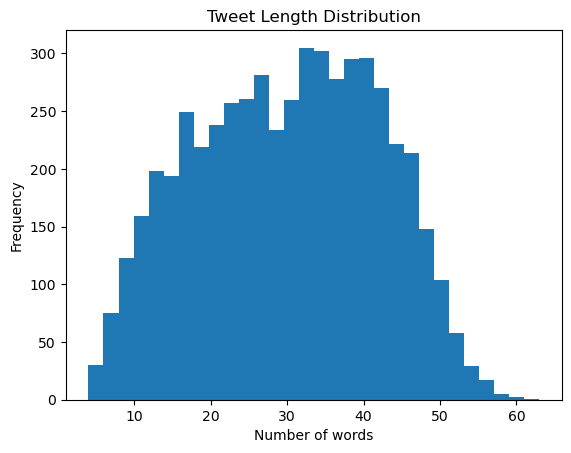

In [31]:
import matplotlib.pyplot as plt

# tweet length
df["length"] = df["clean_text"].apply(lambda x: len(x.split()))

plt.hist(df["length"], bins=30)
plt.title("Tweet Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

Word Frequency Analysis

In [32]:
from collections import Counter

all_words = " ".join(df["clean_text"]).split()

word_freq = Counter(all_words)

print(word_freq.most_common(20))

[('the', 7978), ('volleyball', 4891), ('and', 3289), ('to', 3160), ('in', 3049), ('a', 2965), ('of', 2187), ('for', 2146), ('i', 1440), ('is', 1398), ('on', 1344), ('s', 1317), ('at', 1292), ('with', 1129), ('team', 1070), ('beach', 911), ('this', 880), ('it', 803), ('world', 746), ('championship', 736)]


# 6. Data Annotation (Text for Thesis)

6. Data Annotation

In order to train a supervised machine learning model for emotion classification, the dataset must be annotated with emotion labels. Annotation involves assigning a predefined emotional category to each tweet based on the emotional content expressed in the text.

In this study, the following emotion categories were used:

* neutral
* happiness
* anger
* disgust
* sadness
* surprise
* fear

Each tweet in the dataset was manually reviewed and assigned one of these labels according to the dominant emotional expression present in the text.

Manual annotation ensures higher quality labels compared to automatic labeling methods, although it requires more time and effort. In cases where the emotional content of a tweet was unclear, the tweet was labeled as neutral.

After the annotation process, the labeled dataset was used to train and evaluate machine learning models for emotion classification.

# 7. Baseline Model

Code — Baseline Model

In [43]:
df

,text,model_prediction,clean_text,length
0,10 Years Ago Welling United 0-1 Aldershot Town...,joy,10 years ago welling united 01 aldershot town ...,49
1,Thank you Coach Horton for a wonderful visit t...,joy,thank you coach horton for a wonderful visit t...,21
2,"Remember years ago, softball used to be that w...",joy,remember years ago softball used to be that wa...,52
3,KAMIL SEMENIUK The Italian league champion wil...,neutral,kamil semeniuk the italian league champion wil...,33
4,Nebraska beach volleyball earned a dominant 5-...,joy,nebraska beach volleyball earned a dominant 50...,55
...,...,...,...,...
5319,Micah Christenson is that way too,neutral,micah christenson is that way too,6
5320,GAMEDAY The St. John Fisher men's volleyball t...,neutral,gameday the st john fisher mens volleyball tea...,30
5321,Brag time! My freshman team won their first ma...,joy,brag time my freshman team won their first mat...,31
5322,Yet the whole region has no indoor facility to...,neutral,yet the whole region has no indoor facility to...,22


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X = df["clean_text"]
y = df["model_prediction"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=200)

model.fit(X_train_tfidf, y_train)

preds = model.predict(X_test_tfidf)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

       anger       0.00      0.00      0.00        24
         joy       0.90      0.71      0.80       319
     neutral       0.81      0.96      0.88       678
     sadness       0.60      0.14      0.22        44

    accuracy                           0.83      1065
   macro avg       0.58      0.45      0.47      1065
weighted avg       0.81      0.83      0.81      1065



c:\Users\Payrav\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Payrav\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Payrav\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


1. Confusion Matrix

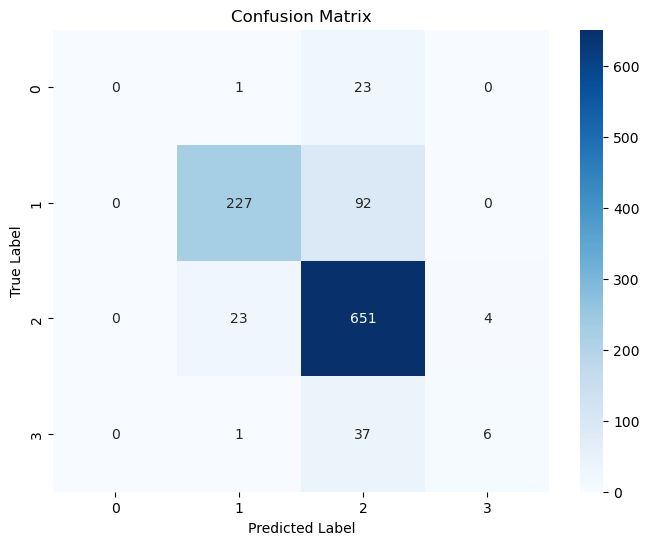

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

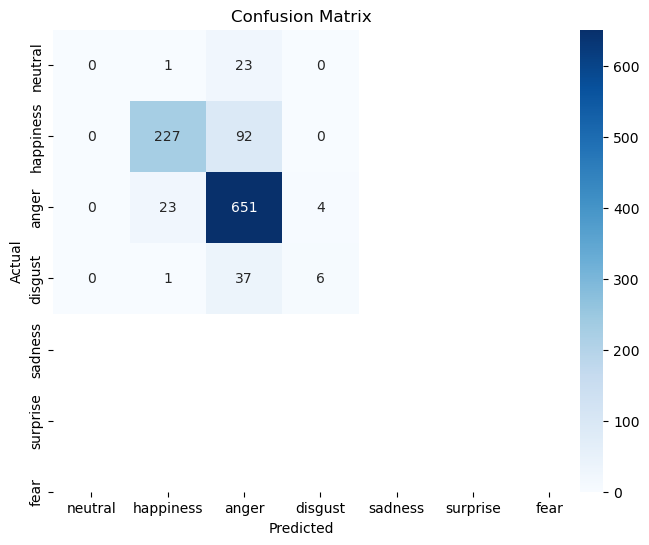

In [109]:
labels = ["neutral","happiness","anger","disgust","sadness","surprise","fear"]

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

2. ROC-AUC (Multi-class)

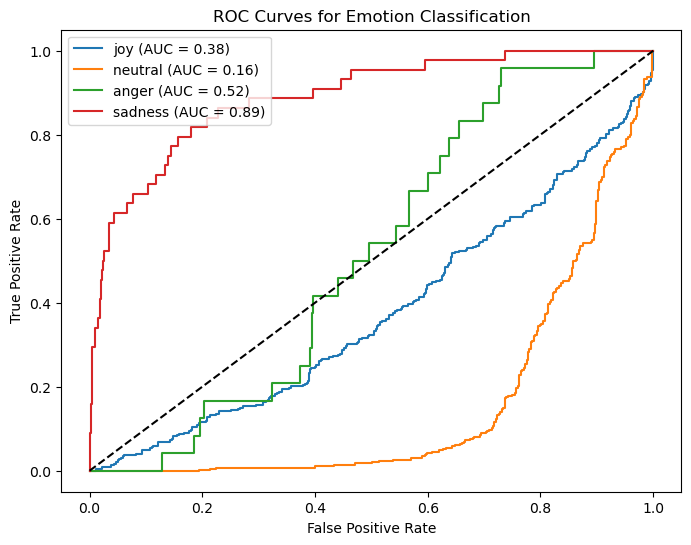

In [35]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

classes = y.unique()
y_test_bin = label_binarize(y_test, classes=classes)

probs = model.predict_proba(X_test_tfidf)

plt.figure(figsize=(8,6))

for i in range(len(classes)):
    
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curves for Emotion Classification")

plt.legend()

plt.show()

3. Precision / Recall / F1 Graph

c:\Users\Payrav\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


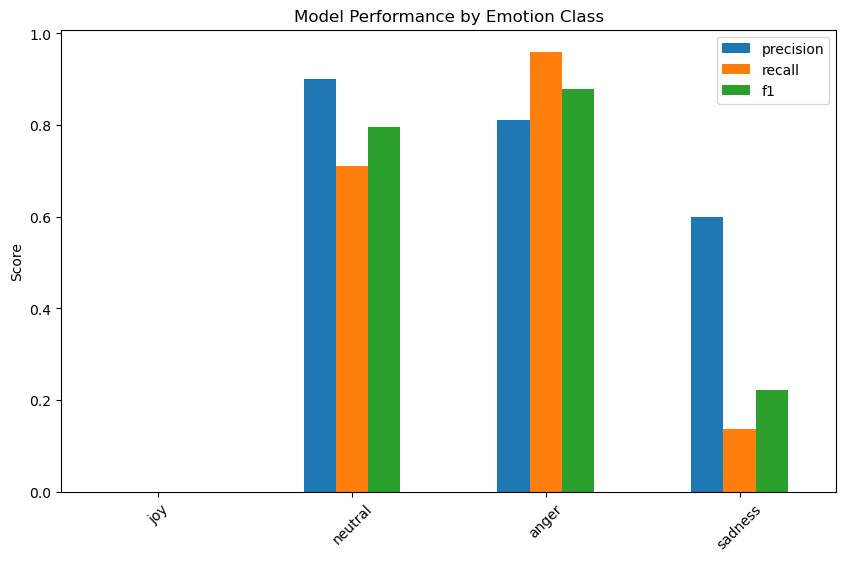

In [36]:
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

precision, recall, f1, _ = precision_recall_fscore_support(y_test, preds)

metrics_df = pd.DataFrame({
    "precision": precision,
    "recall": recall,
    "f1": f1
}, index=classes)

metrics_df.plot(kind="bar", figsize=(10,6))

plt.title("Model Performance by Emotion Class")
plt.ylabel("Score")

plt.xticks(rotation=45)

plt.show()

4. Top Words Important for Model

In [37]:
feature_names = vectorizer.get_feature_names_out()

coefs = model.coef_[0]

top_positive = coefs.argsort()[-20:]
top_negative = coefs.argsort()[:20]

print("Top words for positive emotion:")
print([feature_names[i] for i in top_positive])

print("\nTop words for negative emotion:")
print([feature_names[i] for i in top_negative])

Top words for positive emotion:
['they', 'ends', 'traffic', 'am', 'disappointment', 'serving', 'me', 'other', 'this', 'got', 'is', 'it', 'worst', 'madison', 'whatever', 'terrible', 'ridiculous', 'hate', 'loss', 'made']

Top words for negative emotion:
['lost', 'win', 'set', 'love', 'your', 'won', 'as', 'best', 'spike', 'go', 'amazing', 'you', 'setter', 'game', 'all', 'at', 'victory', 'her', 'im', 'great']


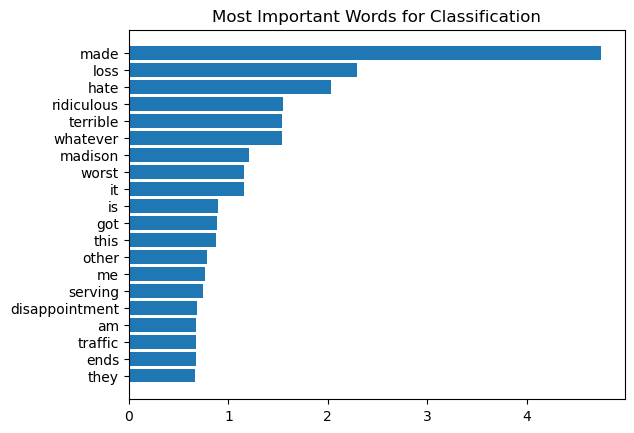

In [38]:
import numpy as np

top_features = np.argsort(np.abs(model.coef_[0]))[-20:]

plt.barh(range(len(top_features)), model.coef_[0][top_features])

plt.yticks(range(len(top_features)), [feature_names[i] for i in top_features])

plt.title("Most Important Words for Classification")

plt.show()

5. Class Distribution

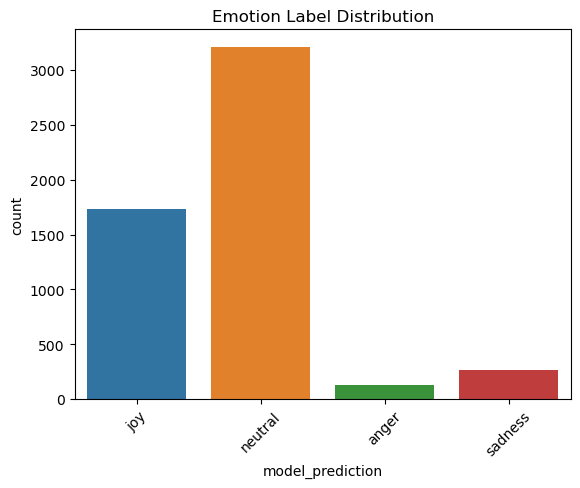

In [39]:
import seaborn as sns

sns.countplot(x=y)

plt.title("Emotion Label Distribution")
plt.xticks(rotation=45)

plt.show()

# 8. BERT Model (Main Model)

In [40]:
!pip install transformers
!pip install torch

BERT Fine-Tuning Code

In [ ]:
from transformers import BertTokenizer
from transformers import BertForSequenceClassification
from transformers import Trainer, TrainingArguments
import torch
from datasets import Dataset

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(batch):
    return tokenizer(batch["clean_text"], padding=True, truncation=True)

dataset = Dataset.from_pandas(df)

dataset = dataset.map(tokenize, batched=True)

dataset = dataset.train_test_split(test_size=0.2)

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=7
)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    evaluation_strategy="epoch"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"]
)

trainer.train()

Evaluation

In [ ]:
trainer.evaluate()